In [9]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision import transforms
import timm
import segmentation_models_pytorch as smp

from pytorch_grad_cam import FinerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [10]:
# Hyperparameters and paths
DATA_DIR = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5/"
NUM_PARTS = 4
CLASSIFIER_NAME = "deit_base_distilled_patch16_224.fb_in1k"
SEGMENTATION_NAME = "deeplabv3plus"
SEGMENTATION_ENCODER = "resnext50_32x4d"
SEGMENTATION_WEIGHTS = r"/home/c/choton/beemachine/codes/AG_vision_2026/2_segmentation/Beemachine/deeplabv3+/lightning_logs/version_0/checkpoints/epoch=199-step=54400.ckpt"
FEATURE_SIZE = 937
IMAGE_SIZE = 224
DEVICE_ID = 0

# The classification models and their timm names
backbone_models = {
    "ConvNext_Nano": "convnext_nano.in12k",
    "DeiT": "deit_base_distilled_patch16_224.fb_in1k",
    # "EfficientNetV2L": "tf_efficientnetv2_l.in21k",
    "EfficientNetV2M": "efficientnetv2_rw_m.agc_in1k",
    "EfficientNetV2S": "efficientnetv2_rw_s.ra2_in1k",
    # "EVA02_Large":"eva02_large_patch14_224.mim_in22k",
    "InceptionNext_Tiny": "inception_next_tiny.sail_in1k",
    "ResNet101": "resnet101.a1_in1k",
    "SeResNext101": "seresnext101_32x4d.gluon_in1k",
    "SWIN_Classifier": "swin_base_patch4_window7_224.ms_in1k",
}

# The weights of the PADC models
padc_weights = {
    "ConvNext_Nano": r"/home/c/choton/beemachine/codes/AG_vision_2026/PADC/Beemachine/PADC_Ablation/PADC_ab_convnext_nano_fixed_logs/checkpoints/best_model.pth",
    "DeiT": r"/home/c/choton/beemachine/codes/AG_vision_2026/PADC/Beemachine/PADC_Ablation/padc_ab_deit_fixed_logs/checkpoints/best_model.pth",
    # "EfficientNetV2L": "tf_efficientnetv2_l.in21k",
    "EfficientNetV2M": "/home/c/choton/beemachine/codes/AG_vision_2026/PADC/Beemachine/PADC_Ablation/padc_arch2_effnet_v2m_fixed_logs/checkpoints/best_model.pth",
    "EfficientNetV2S": "/home/c/choton/beemachine/codes/AG_vision_2026/PADC/Beemachine/PADC_Ablation/padc_arch2_effnets_fixed_logs/checkpoints/best_model.pth",
    # "EVA02_Large":"eva02_large_patch14_224.mim_in22k",
    "InceptionNext_Tiny": "/home/c/choton/beemachine/codes/AG_vision_2026/PADC/Beemachine/PADC_Ablation/padc_arch2_inceptionnext_tiny_fixed_logs/checkpoints/best_model.pth",
    "ResNet101": "/home/c/choton/beemachine/codes/AG_vision_2026/PADC/Beemachine/PADC_Ablation/padc_arch2_resnet101_fixed_logs/checkpoints/best_model.pth",
    "SeResNext101": "/home/c/choton/beemachine/codes/AG_vision_2026/PADC/Beemachine/PADC_Ablation/padc_arch2_se_resnext101_fixed_logs/checkpoints/best_model.pth",
    "SWIN_Classifier": "/home/c/choton/beemachine/codes/AG_vision_2026/PADC/Beemachine/PADC_Ablation/padc_arch2_swin_fixed_logs/checkpoints/best_model.pth",
}

# The weights of the baseline models
baseline_weights = {
    "ConvNext_Nano": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/Beemachine/convnext_nano.in12k_timm_new_dataset_logs/checkpoints/best_model.pth",
    "DeiT": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/Beemachine/deit_base_distilled_patch16_224.fb_in1k_timm_new_dataset_logs/checkpoints/best_model.pth",
    # "EfficientNetV2L": "tf_efficientnetv2_l.in21k",
    "EfficientNetV2M": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/Beemachine/efficientnetv2_rw_m.agc_in1k_timm_logs/checkpoints/best_model.pth",
    "EfficientNetV2S": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/Beemachine/efficientnetv2_rw_s.ra2_in1k_timm_v1_logs/checkpoints/best_model.pth",
    # "EVA02_Large":"eva02_large_patch14_224.mim_in22k",
    "InceptionNext_Tiny": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/Beemachine/inception_next_tiny.sail_in1k_timm_new_dataset_logs/checkpoints/best_model.pth",
    "ResNet101": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/Beemachine/resnet101.a1_in1k_timm_new_dataset_logs/checkpoints/best_model.pth",
    "SeResNext101": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/Beemachine/seresnext101_32x4d.gluon_in1k_timm_new_dataset_logs/checkpoints/best_model.pth",
    "SWIN_Classifier": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/Beemachine/swin_base_patch4_window7_224.ms_in1k_timm_new_dataset_logs/checkpoints/best_model.pth",
}

classifier_names = list(padc_weights.keys())

In [11]:
# Load segmentation model
def load_segmentation(name, encoder_name, checkpoint_path):    
    # Define the segmentation model and load weights
    model = smp.create_model(
                name,
                encoder_name=encoder_name,
                in_channels = 3, # 3 for RGB images
                classes = NUM_PARTS
            ).to(f"cuda:{DEVICE_ID}")
    checkpoint = torch.load(checkpoint_path, map_location=rf"cuda:{DEVICE_ID}")

    # Sometimes Lightning adds "state_dict"
    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
        # Remove "model." or "net." prefixes if present
        new_state_dict = {k.replace("model.", "").replace("net.", ""): v 
                        for k, v in state_dict.items() if k not in ["mean", "std"]}
        model.load_state_dict(new_state_dict)
    else:
        model.load_state_dict(checkpoint)
    return model

def extract_all_features(image_np, mask_np):
    # Return dummy shapes
    record = {f'part_{i}': 0 for i in range(FEATURE_SIZE)}
    return record

In [12]:
class SpeciesDataset(Dataset):
    def __init__(self, df, img_dir, image_size):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.4925, 0.4475, 0.3490), # Custom normalization values for beemachine_small_2025_v3 (segmentation) dataset
                             std=(0.2392, 0.2265, 0.2213))
        # transforms.Normalize(mean=[0.485, 0.456, 0.406], # Imagenet Normalization values
        #              std=[0.229, 0.224, 0.225])
        ])
        self.num_classes = self.df["label"].nunique()
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "image"]
        label = self.df.loc[idx, "label"]
        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label, img_path

In [13]:
# Load the train and validation dataset
train_datapath = os.path.join(DATA_DIR, 'train_aug_labels.csv')
val_datapath = os.path.join(DATA_DIR, 'val_labels.csv')
test_datapath = os.path.join(DATA_DIR, 'test_labels.csv')
train_df = pd.read_csv(train_datapath) 
val_df = pd.read_csv(val_datapath) 
test_df = pd.read_csv(test_datapath)

le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["species"])
val_df["label"] = le.transform(val_df["species"])
test_df["label"] = le.transform(test_df["species"])
num_classes = len(le.classes_)
print(f"Total images, Train: {len(train_df['label'])}, Validation: {len(val_df['label'])}, Test: {len(test_df['label'])}")
print(f"Total classes: {num_classes}")

train_path = os.path.join(DATA_DIR, "train", 'aug_images') # Path for the training data
val_path = os.path.join(DATA_DIR, "valid", 'images') # Path for validation data
test_path = os.path.join(DATA_DIR, "test", 'images') # Path for testing data
train_dataset = SpeciesDataset(df=train_df, img_dir=train_path, image_size=IMAGE_SIZE)
val_dataset = SpeciesDataset(df=val_df, img_dir=val_path, image_size=IMAGE_SIZE)
test_dataset = SpeciesDataset(df=test_df, img_dir=test_path, image_size=IMAGE_SIZE)

num_classes = train_dataset.num_classes
device = torch.device(f"cuda:{DEVICE_ID}")
print(f"Dataset info: Classes: {num_classes} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Total images, Train: 34722, Validation: 1158, Test: 771
Total classes: 160
Dataset info: Classes: 160 | Train: 34722 | Val: 1158 | Test: 771


In [14]:
class ShapeEncoder(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
            )
        self.fc = nn.Linear(128, embed_dim)

    def forward(self, mask_tensor):        # mask_tensor: (B, 3, 64, 64)
        feat = self.encoder(mask_tensor)
        feat = feat.flatten(1)
        z = self.fc(feat)
        return z  

class GatedFusion(nn.Module):
    def __init__(self, img_dim, shape_dim):
        super().__init__()
        self.shape_proj = nn.Linear(shape_dim, img_dim)
        self.gate = nn.Sequential(
            nn.Linear(img_dim + img_dim, img_dim),
            nn.LayerNorm(img_dim),
            nn.Sigmoid()
        )

    def forward(self, z_img, z_shape):
        z_shape_proj = self.shape_proj(z_shape)
        concat = torch.cat([z_img, z_shape_proj], dim=1)
        g = self.gate(concat)
        fused = z_img + g * (z_shape_proj - z_img)
        return fused

class DeepShapeFusionModel(nn.Module):
    def __init__(self, num_classes, classifier_name, shape_embed_dim=256):
        super().__init__()
        self.num_shape_feats = FEATURE_SIZE

        # Modules
        self.seg_module = load_segmentation(
            name=SEGMENTATION_NAME, 
            encoder_name=SEGMENTATION_ENCODER, 
            checkpoint_path=SEGMENTATION_WEIGHTS
        )
        self.backbone = timm.create_model(model_name=classifier_name, pretrained=True, num_classes=0)
        self.shape_encoder = ShapeEncoder(shape_embed_dim)
        self.feature_dim = self.backbone.num_features

        self.fusion = GatedFusion(
            img_dim=self.backbone.num_features,
            shape_dim=shape_embed_dim
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        total_feats = self.backbone.num_features # + self.num_shape_feats # + shape_embed_dim
        self.classifier = nn.Sequential(
                                nn.LayerNorm(total_feats),
                                nn.Dropout(0.3),
                                nn.Linear(total_feats, num_classes)
                            )
        for p in self.seg_module.parameters():
            p.requires_grad = False
        self.seg_module.eval()

    def forward(self, x, shape_feats=None):
        # ---- Segmentation ----
        with torch.no_grad():
            mask_logits = self.seg_module(x)
            masks = torch.argmax(mask_logits, dim=1)  # (B, H, W) with labels 0,1,2,3

        # Extract part embeddings
        parts = mask_logits[:, 1:, :, :]  # remove background, will try mask_probs as well
        mask_binary = parts.sum(dim=1, keepdim=True)
        edge = torch.abs(
            torch.nn.functional.avg_pool2d(mask_binary, 3, stride=1, padding=1)
            - mask_binary
        )
        shape_tensor = torch.cat([mask_binary, edge, mask_binary], dim=1)
        z_shape = self.shape_encoder(shape_tensor)

        # ---- Extract hand-crafted shape descriptors ----
        # ---- Shape features ----
        if shape_feats is None:
            batch_size = x.size(0)
            batch_feats = []
            for i in range(batch_size):
                img_np = x[i].detach().cpu().numpy().transpose(1, 2, 0)
                mask_np = masks[i].detach().cpu().numpy()
                feats_dict = extract_all_features(img_np, mask_np)
                # Convert dict to tensor (relies on consistent insertion order for 937 features)
                feat_tensor = torch.tensor(list(feats_dict.values()), dtype=torch.float32)
                batch_feats.append(feat_tensor)
            shape_feats = torch.stack(batch_feats).to(x.device)  # (B, 937)
        # shape_feats = torch.tensor(shape_feats).to(x.device)        

        # ---- Image Encoding ----
        z_img = self.backbone.forward_features(x)

        # Make layout agnostic: if NHWC (common for Swin), permute to NCHW
        if z_img.dim() == 4 and z_img.shape[1] != self.feature_dim:
            # Assume NHWC if channels are in last dim
            z_img = z_img.permute(0, 3, 1, 2)  # → [B, C, H, W]
        
        if z_img.dim() == 3:  # Token-based (ViT/DeiT style)
            # For distilled DeiT: cls token at index 0, distillation token at index 1
            # → Use cls token (most common) or average cls + distill for better performance
            # z_img = z_img[:, 0]  # [B, 768] – cls token (recommended for classification tasks)
            # Alternative (often slightly better for distilled models):
            z_img = z_img[:, :2].mean(dim=1)  # average cls + distill token → [B, 768]

        else:  # 4D spatial feature map (conv or Swin-style)
            # Ensure NCHW layout
            if z_img.dim() == 4 and z_img.shape[1] != self.feature_dim:
                z_img = z_img.permute(0, 3, 1, 2)  # NHWC → NCHW

            # Now safe to pool (expects NCHW)      
            # z_img = z_img.mean(-1).mean(-1)
            z_img = self.global_pool(z_img) # → [B, C, 1, 1]
            z_img = z_img.flatten(start_dim=1) # → [B, C]
        # print("Shape of extracted features from visual,", z_img.shape)
        fused = self.fusion(z_img, z_shape)
        # combined = torch.cat([fused, shape_feats], dim=1)  # (B, total_feats)
        combined = fused # Ablation study
        out = self.classifier(combined)
        return out, mask_logits, z_shape


In [15]:
def plot_cam(model, img_path, label, cam_method, transform, ax):
    image_pil = Image.open(img_path).convert("RGB")
    input_tensor = transform(image_pil).unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(label)]
    
    # Forward pass (optional check)
    with torch.no_grad():
        output = model(input_tensor)
    if type(output) is tuple: # If the model returns a tuple, only take the first output
        output = output[0]
    pred = output.argmax(dim=1).item()
    print(f"True label: {label}")
    print(f"Predicted: {pred}")

    # Generate CAM
    grayscale_cam = cam_method(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]  # remove batch dim

    # Overlay (Correct Version)
    rgb_img = np.array(image_pil).astype(np.float32) / 255.0

    # Resize CAM to original image size
    grayscale_cam = cv2.resize(grayscale_cam, (rgb_img.shape[1], rgb_img.shape[0]))
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    ax.imshow(visualization)
    ax.axis("off")

# 🔥 IMPORTANT: reshape for DeiT
def reshape_transform_deit(tensor):
    # Remove CLS token if it exists
    if tensor.shape[1] == (int(tensor.shape[1] ** 0.5 + 0.5) ** 2) + 1:
        tensor = tensor[:, 1:, :]
    B, N, C = tensor.shape

    # Compute H and W dynamically
    H = W = int(N ** 0.5)
    if H * W != N:
        # Not perfect square → approximate rectangle
        H = int(N ** 0.5)
        W = int(np.ceil(N / H))
        if H * W != N:
            # Pad with zeros if necessary
            pad = H * W - N
            tensor = torch.cat([tensor, tensor.new_zeros(B, pad, C)], dim=1)
    tensor = tensor.reshape(B, H, W, C)
    tensor = tensor.permute(0, 3, 1, 2)
    return tensor

# Reshape for swin transformer
def reshape_transform_swin(tensor):
    # tensor is (B, H, W, C)
    return tensor.permute(0, 3, 1, 2)

def get_reshape_transform(model_name):
    if 'deit' in model_name.lower():
        return reshape_transform_deit
    elif 'swin' in model_name.lower():
        return reshape_transform_swin
    else:
        return None

In [16]:
classifier_name = classifier_names[1]
state_dict = torch.load(padc_weights[classifier_name], map_location=device)
model = DeepShapeFusionModel(num_classes=num_classes, classifier_name=backbone_models[classifier_name], shape_embed_dim=512)
model.to(device)
model.load_state_dict(state_dict)
model.eval()

DeepShapeFusionModel(
  (seg_module): DeepLabV3Plus(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_runni

In [17]:
img, lbl, img_path = test_dataset[100]
outputs, mask_logits, z_shape = model(img.unsqueeze(0).to(device))
_, preds = outputs.max(1)
preds, lbl, preds.eq(lbl), mask_logits.shape, z_shape.shape

(tensor([49], device='cuda:0'),
 49,
 tensor([True], device='cuda:0'),
 torch.Size([1, 4, 224, 224]),
 torch.Size([1, 512]))

True label: 121
Predicted: 191


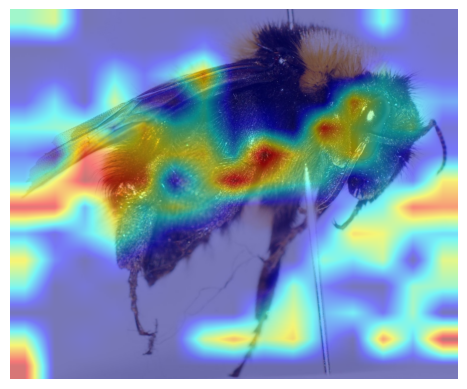

In [18]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

# FinerCAM Setup. Target layer: (last block norm)
target_layers = [model.backbone.blocks[-1].norm1]
cam = FinerCAM(
    model=model.backbone,
    target_layers=target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model.backbone, img_path=img_path, label=lbl, cam_method=cam, transform=test_dataset.transform, ax=axes)

True label: 121
Predicted: 191


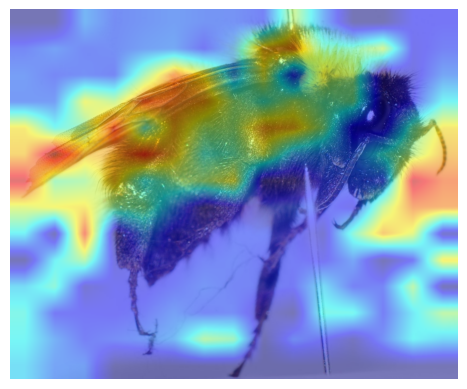

In [19]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

# FinerCAM Setup. Target layer: (last block norm)
target_layers = [model.backbone.blocks[-1].norm2]
cam = FinerCAM(
    model=model.backbone,
    target_layers=target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model.backbone, img_path=img_path, label=lbl, cam_method=cam, transform=test_dataset.transform, ax=axes)

Convnext_nano

True label: 121
Predicted: 121
True label: 121
Predicted: 121


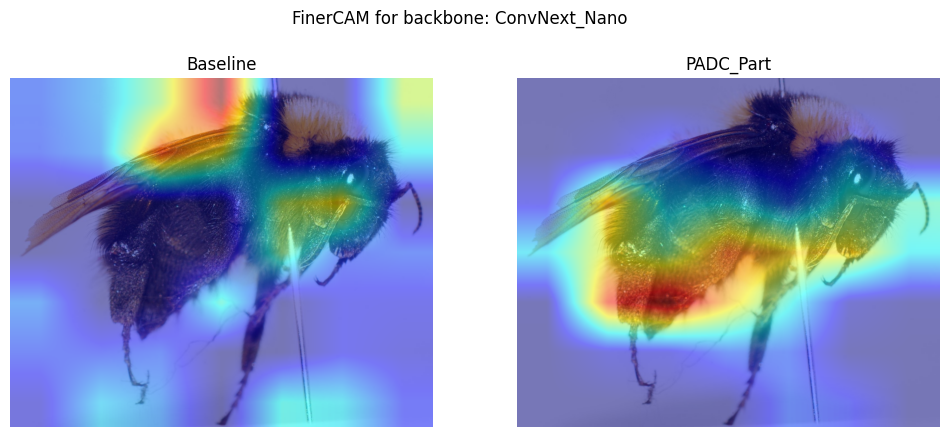

In [20]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

classifier_name = "ConvNext_Nano"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.stages[-1]]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.stages[-1]]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()

DeiT

True label: 121
Predicted: 121
True label: 121
Predicted: 121


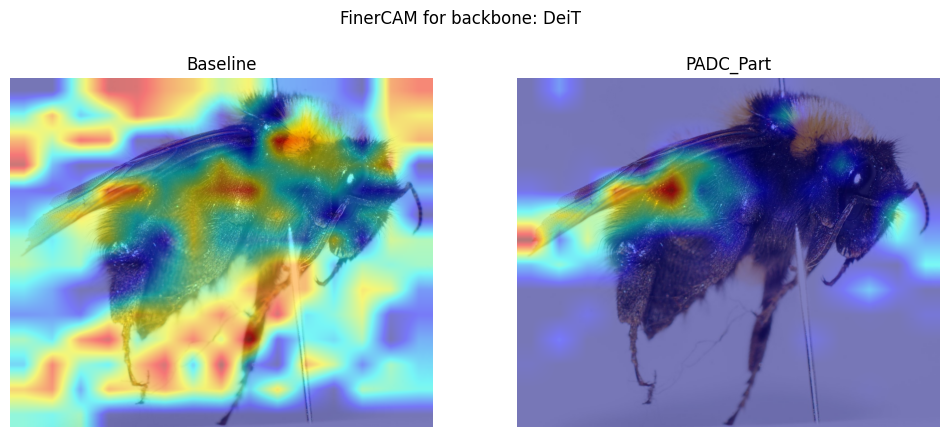

In [21]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]
classifier_name = "DeiT"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.blocks[-1].norm2]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.blocks[-1].norm2]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()

True label: 121
Predicted: 146
True label: 121
Predicted: 121


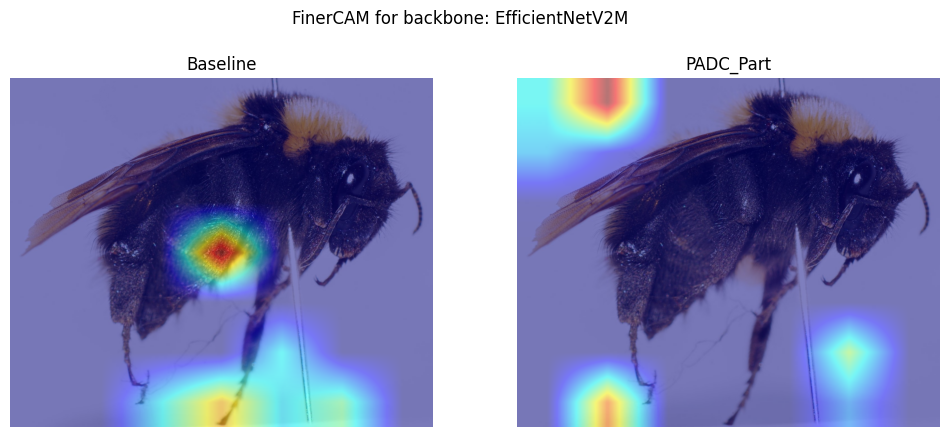

In [22]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]
classifier_name = "EfficientNetV2M"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.conv_head]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.conv_head]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()

True label: 121
Predicted: 121
True label: 121
Predicted: 121


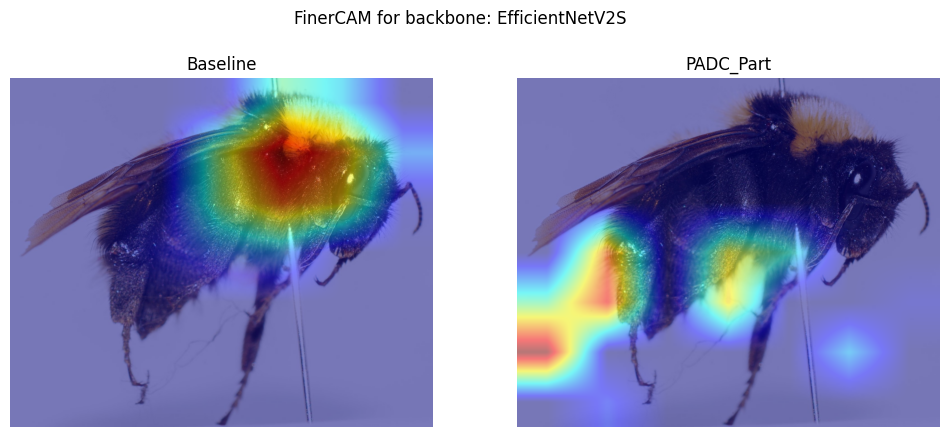

In [23]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]
classifier_name = "EfficientNetV2S"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.conv_head]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.conv_head]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()

True label: 121
Predicted: 121


/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/torch/nn/init.py:566: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


True label: 121
Predicted: 121


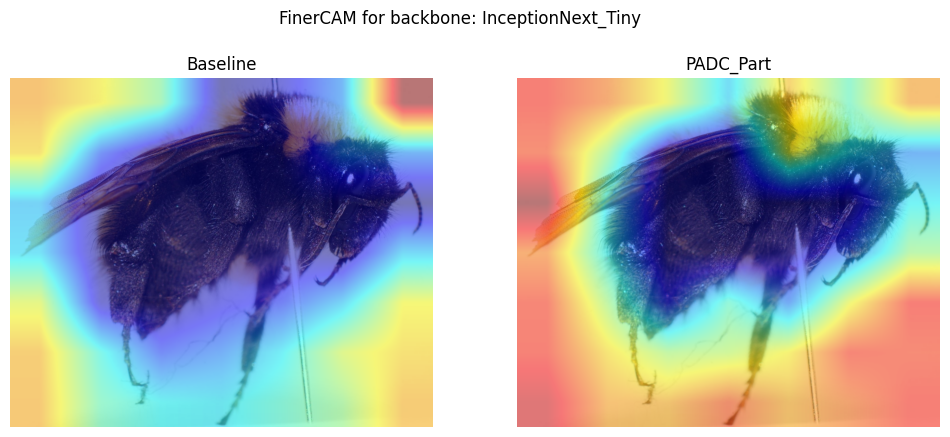

In [24]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]
classifier_name = "InceptionNext_Tiny"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.stages[-1].blocks[-1].norm]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.stages[-1].blocks[-1].norm]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()

True label: 121
Predicted: 121
True label: 121
Predicted: 121


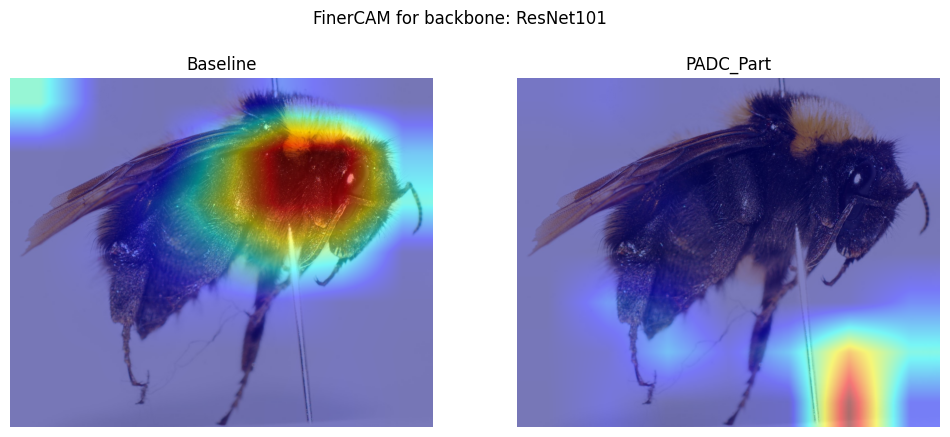

In [25]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]
classifier_name = "ResNet101"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.layer4[-1]]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.layer4[-1]]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()

True label: 121
Predicted: 121
True label: 121
Predicted: 121


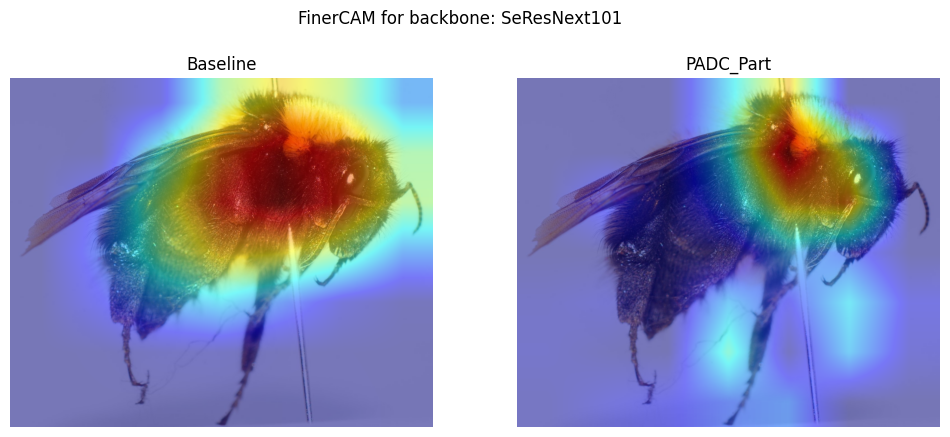

In [26]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]
classifier_name = "SeResNext101"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.layer4[-1]]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.layer4[-1]]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()

True label: 121
Predicted: 121
True label: 121
Predicted: 121


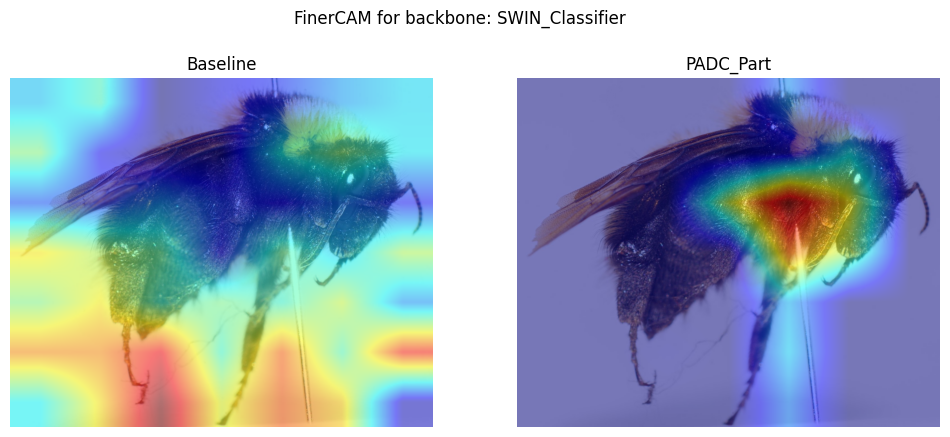

In [27]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]
classifier_name = "SWIN_Classifier"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.layers[-1]]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.layers[-1]]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()